In [15]:
import re
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [7]:
def parse_results(filepath):
    """
    Parses the AREA COMPARISON table from results.txt.
    Returns a nested dict: { rBH: { grid_label: err_pct } }
    """
    data = {}
    in_table = False
 
    with open(filepath) as f:
        for line in f:
            if "AREA COMPARISON" in line:
                in_table = True
                continue
            if not in_table:
                continue
            # Match data rows: e.g. " 1.00   0.500  32x32  ..."
            m = re.match(
                r"\s*([\d.]+)\s+([\d.]+)\s+(\S+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\w+)",
                line
            )
            if m:
                rBH     = float(m.group(1))
                grid    = m.group(3)
                pct_err = float(m.group(6))
                data.setdefault(rBH, {})[grid] = pct_err
 
    return data


RESULTS_FILE = "results.txt"   # adjust path if needed
 
sep_colors  = ["#378ADD", "#1D9E75", "#BA7517", "#D4537E", "#7F77DD", "#E24B4A"]
grid_colors = ["#E24B4A", "#BA7517", "#1D9E75", "#378ADD"]
grid_N      = {"32x32": 32, "48x48": 48, "64x64": 64, "100x100": 100}

In [8]:
data        = parse_results(RESULTS_FILE)
separations = sorted(data.keys())
grids       = sorted(next(iter(data.values())).keys(), key=lambda g: grid_N[g])
N_vals      = [grid_N[g] for g in grids]

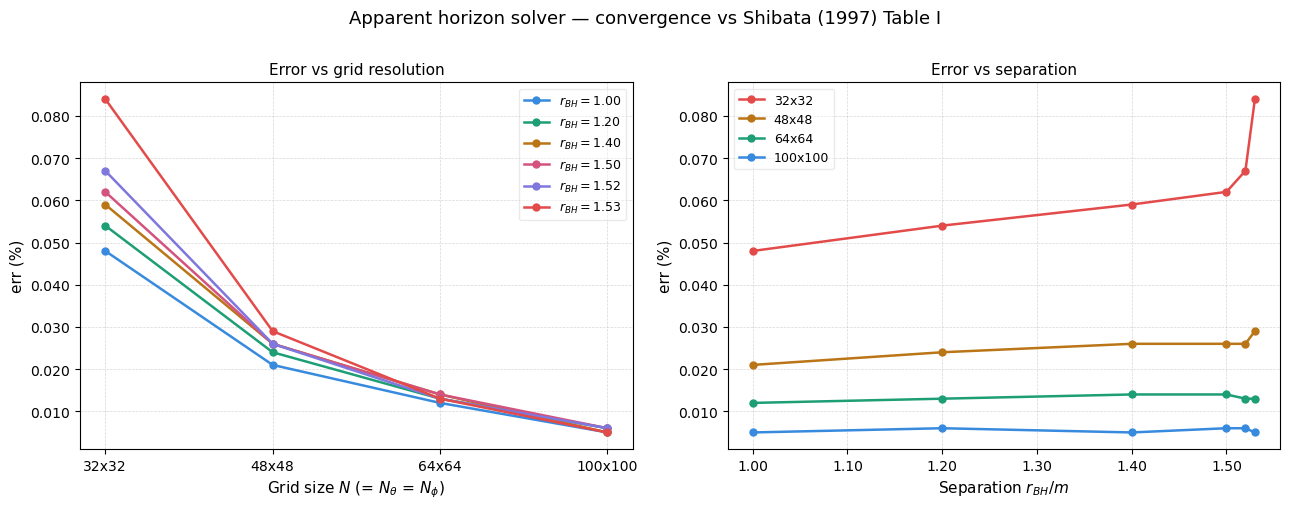

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Apparent horizon solver — convergence vs Shibata (1997) Table I",
             fontsize=13, y=1.01)

# Plot 1: error vs grid size
ax1 = axes[0]
x_pos = range(len(grids))
for sep, color in zip(separations, sep_colors):
    errs = [data[sep][g] for g in grids]
    ax1.plot(x_pos, errs, marker="o", color=color, linewidth=1.8,
             markersize=5, label=f"$r_{{BH}}={sep:.2f}$")
 
ax1.set_xlabel("Grid size $N$ (= $N_\\theta$ = $N_\\phi$)", fontsize=11)
ax1.set_ylabel("err (%)", fontsize=11)
ax1.set_title("Error vs grid resolution", fontsize=11)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(grids, fontsize=10)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax1.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax1.legend(fontsize=9, framealpha=0.4)
 
# Plot 2: error vs separation
ax2 = axes[1]
for grid, color in zip(grids, grid_colors):
    errs = [data[sep][grid] for sep in separations]
    ax2.plot(separations, errs, marker="o", color=color, linewidth=1.8,
             markersize=5, label=grid)
 
ax2.set_xlabel("Separation $r_{BH}/m$", fontsize=11)
ax2.set_ylabel("err (%)", fontsize=11)
ax2.set_title("Error vs separation", fontsize=11)
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
ax2.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax2.legend(fontsize=9, framealpha=0.4)
 
plt.tight_layout()
plt.savefig("convergence_plots.png", dpi=150, bbox_inches="tight")
plt.show()